In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [21]:
from google.colab import files
uploaded = files.upload()


Saving train.csv to train (1).csv


In [22]:
df = pd.read_csv('train.csv')
print(df.shape)
print(df.isnull().sum().sum(), 'missing values')
print('pixel range:', df.drop(columns='label').values.min(), 'to', df.drop(columns='label').values.max())
df.head()

(42000, 785)
0 missing values
pixel range: 0 to 255


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


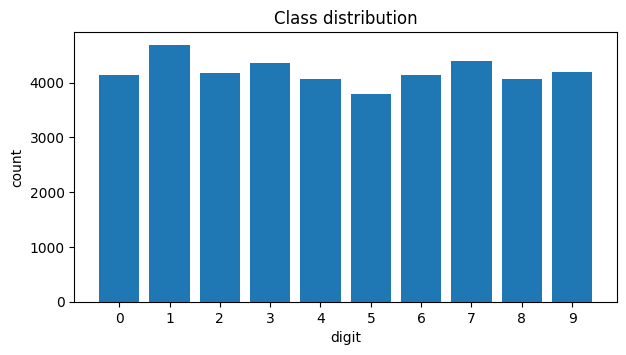

label
0     9.84
1    11.15
2     9.95
3    10.36
4     9.70
5     9.04
6     9.85
7    10.48
8     9.67
9     9.97
Name: count, dtype: float64


In [23]:
counts = df['label'].value_counts().sort_index()
plt.figure(figsize=(7,3.5))
plt.bar(counts.index, counts.values)
plt.xticks(range(10)); plt.xlabel('digit'); plt.ylabel('count'); plt.title('Class distribution')
plt.show()
print((counts / len(df) * 100).round(2))

##  Preprocessing

In [24]:
X = X_raw.astype(np.float64) / 255.0          # scale to [0, 1]

def one_hot(y, num_classes=10):
    out = np.zeros((len(y), num_classes))
    out[np.arange(len(y)), y] = 1
    return out

# stratified 80/10/10 split, done by hand so every class keeps its proportion
rng = np.random.default_rng(42)
train_idx, val_idx, test_idx = [], [], []
for d in range(10):
    idx = rng.permutation(np.where(y_raw == d)[0])
    n_train = int(0.8 * len(idx)); n_val = int(0.1 * len(idx))
    train_idx += list(idx[:n_train])
    val_idx   += list(idx[n_train:n_train + n_val])
    test_idx  += list(idx[n_train + n_val:])

train_idx = rng.permutation(train_idx); val_idx = rng.permutation(val_idx); test_idx = rng.permutation(test_idx)

X_train, y_train = X[train_idx], y_raw[train_idx]
X_val,   y_val   = X[val_idx],   y_raw[val_idx]
X_test,  y_test  = X[test_idx],  y_raw[test_idx]
Y_train, Y_val, Y_test = one_hot(y_train), one_hot(y_val), one_hot(y_test)

print(X_train.shape, X_val.shape, X_test.shape)

(33595, 784) (4196, 784) (4209, 784)




##  The network


In [25]:
def init_params(layer_sizes, seed=0):
    # layer_sizes e.g. [784, 128, 10]
    rng = np.random.default_rng(seed)
    params = {}
    for l in range(1, len(layer_sizes)):
        fan_in = layer_sizes[l - 1]
        params[f'W{l}'] = rng.normal(0, np.sqrt(2.0 / fan_in), (fan_in, layer_sizes[l]))   # He init
        params[f'b{l}'] = np.zeros((1, layer_sizes[l]))
    return params

def relu(Z):
    return np.maximum(0, Z)

def relu_grad(Z):
    return (Z > 0).astype(Z.dtype)

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)      # subtract max for numerical stability
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

In [26]:
def forward(X, params):
    # works for any number of layers: ReLU on hidden layers, softmax on the last one
    L = sum(1 for k in params if k.startswith('W'))
    cache = {'A0': X}
    A = X
    for l in range(1, L + 1):
        Z = A @ params[f'W{l}'] + params[f'b{l}']
        A = softmax(Z) if l == L else relu(Z)
        cache[f'Z{l}'] = Z
        cache[f'A{l}'] = A
    return A, cache

def cross_entropy(A_out, Y):
    # mean over the batch of -sum_k y_k * log(p_k)
    return -np.mean(np.sum(Y * np.log(A_out + 1e-12), axis=1))

def backward(cache, Y, params):
    L = sum(1 for k in params if k.startswith('W'))
    m = Y.shape[0]
    grads = {}
    dZ = (cache[f'A{L}'] - Y) / m                      # softmax + cross-entropy shortcut
    for l in range(L, 0, -1):
        grads[f'dW{l}'] = cache[f'A{l-1}'].T @ dZ
        grads[f'db{l}'] = dZ.sum(axis=0, keepdims=True)
        if l > 1:
            dZ = (dZ @ params[f'W{l}'].T) * relu_grad(cache[f'Z{l-1}'])
    return grads

def update(params, grads, lr):
    # plain gradient descent, in place
    for k in params:
        params[k] -= lr * grads['d' + k]

def predict(X, params):
    A, _ = forward(X, params)
    return A.argmax(axis=1)

##  Gradient check


In [27]:
def grad_check(params, X, Y, key='W1', n_checks=5, eps=1e-5):
    A, cache = forward(X, params)
    grads = backward(cache, Y, params)
    for _ in range(n_checks):
        i = np.random.randint(params[key].shape[0]); j = np.random.randint(params[key].shape[1])
        old = params[key][i, j]
        params[key][i, j] = old + eps; lp = cross_entropy(forward(X, params)[0], Y)
        params[key][i, j] = old - eps; lm = cross_entropy(forward(X, params)[0], Y)
        params[key][i, j] = old
        num = (lp - lm) / (2 * eps); ana = grads['d' + key][i, j]
        print(f'{key}[{i},{j}]  numerical={num:.3e}  analytic={ana:.3e}  rel diff={abs(num-ana)/(abs(num)+abs(ana)+1e-12):.2e}')

p = init_params([784, 16, 10])
grad_check(p, X_train[:5], Y_train[:5], 'W1')
grad_check(p, X_train[:5], Y_train[:5], 'W2')

W1[102,3]  numerical=0.000e+00  analytic=0.000e+00  rel diff=0.00e+00
W1[270,10]  numerical=-7.808e-03  analytic=-7.808e-03  rel diff=2.01e-10
W1[71,12]  numerical=0.000e+00  analytic=0.000e+00  rel diff=0.00e+00
W1[20,6]  numerical=0.000e+00  analytic=0.000e+00  rel diff=0.00e+00
W1[121,2]  numerical=0.000e+00  analytic=0.000e+00  rel diff=0.00e+00
W2[6,7]  numerical=3.208e-02  analytic=3.208e-02  rel diff=1.84e-10
W2[4,3]  numerical=-1.242e-01  analytic=-1.242e-01  rel diff=5.35e-11
W2[7,7]  numerical=1.025e-02  analytic=1.025e-02  rel diff=6.07e-10
W2[2,5]  numerical=1.826e-02  analytic=1.826e-02  rel diff=3.59e-11
W2[4,1]  numerical=8.287e-02  analytic=8.287e-02  rel diff=4.90e-11


## Training loop

In [28]:
import time

def evaluate(X, Y, y, params):
    A, _ = forward(X, params)
    return cross_entropy(A, Y), np.mean(A.argmax(axis=1) == y)

def train(layer_sizes, lr, batch_size, epochs, seed=0, verbose=True):
    params = init_params(layer_sizes, seed)
    rng = np.random.default_rng(seed)
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    n = X_train.shape[0]
    t0 = time.time()
    for epoch in range(epochs):
        perm = rng.permutation(n)                       # reshuffle every epoch
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            A, cache = forward(X_train[idx], params)
            grads = backward(cache, Y_train[idx], params)
            update(params, grads, lr)
        tl, ta = evaluate(X_train, Y_train, y_train, params)
        vl, va = evaluate(X_val, Y_val, y_val, params)
        for k, v in zip(hist, (tl, ta, vl, va)):
            hist[k].append(v)
        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f'epoch {epoch+1:3d}  train loss {tl:.4f} acc {ta:.4f}  |  val loss {vl:.4f} acc {va:.4f}')
    return params, hist, time.time() - t0

In [29]:
# sanity run with the baseline before launching experiments
base_params, base_hist, base_time = train([784, 128, 10], lr=0.1, batch_size=128, epochs=10)
print(f'{base_time:.1f}s')

epoch   1  train loss 0.3241 acc 0.9090  |  val loss 0.3364 acc 0.9082
epoch   6  train loss 0.1519 acc 0.9574  |  val loss 0.1822 acc 0.9476
epoch  10  train loss 0.1116 acc 0.9689  |  val loss 0.1488 acc 0.9578
20.3s


## Experiments


In [30]:
EPOCHS = 15
experiments = {
    # learning rate
    'lr=0.01':  dict(layer_sizes=[784, 128, 10], lr=0.01, batch_size=128),
    'lr=0.1':   dict(layer_sizes=[784, 128, 10], lr=0.1,  batch_size=128),
    'lr=0.5':   dict(layer_sizes=[784, 128, 10], lr=0.5,  batch_size=128),
    # batch size
    'bs=32':    dict(layer_sizes=[784, 128, 10], lr=0.1, batch_size=32),
    'bs=512':   dict(layer_sizes=[784, 128, 10], lr=0.1, batch_size=512),
    # architecture
    'h=64':     dict(layer_sizes=[784, 64, 10],      lr=0.1, batch_size=128),
    'h=256':    dict(layer_sizes=[784, 256, 10],     lr=0.1, batch_size=128),
    'h=128-64': dict(layer_sizes=[784, 128, 64, 10], lr=0.1, batch_size=128),
}

results = {}
for name, cfg in experiments.items():
    print('---', name)
    p, h, t = train(epochs=EPOCHS, verbose=False, **cfg)
    results[name] = dict(params=p, hist=h, time=t, cfg=cfg)
    print(f'final val acc {h["val_acc"][-1]:.4f}  val loss {h["val_loss"][-1]:.4f}  time {t:.1f}s')

--- lr=0.01
final val acc 0.9185  val loss 0.2948  time 24.7s
--- lr=0.1
final val acc 0.9628  val loss 0.1254  time 24.5s
--- lr=0.5
final val acc 0.9735  val loss 0.0959  time 21.4s
--- bs=32
final val acc 0.9707  val loss 0.0950  time 31.3s
--- bs=512
final val acc 0.9371  val loss 0.2194  time 22.2s
--- h=64
final val acc 0.9588  val loss 0.1462  time 14.6s
--- h=256
final val acc 0.9645  val loss 0.1230  time 41.8s
--- h=128-64
final val acc 0.9671  val loss 0.1144  time 23.7s


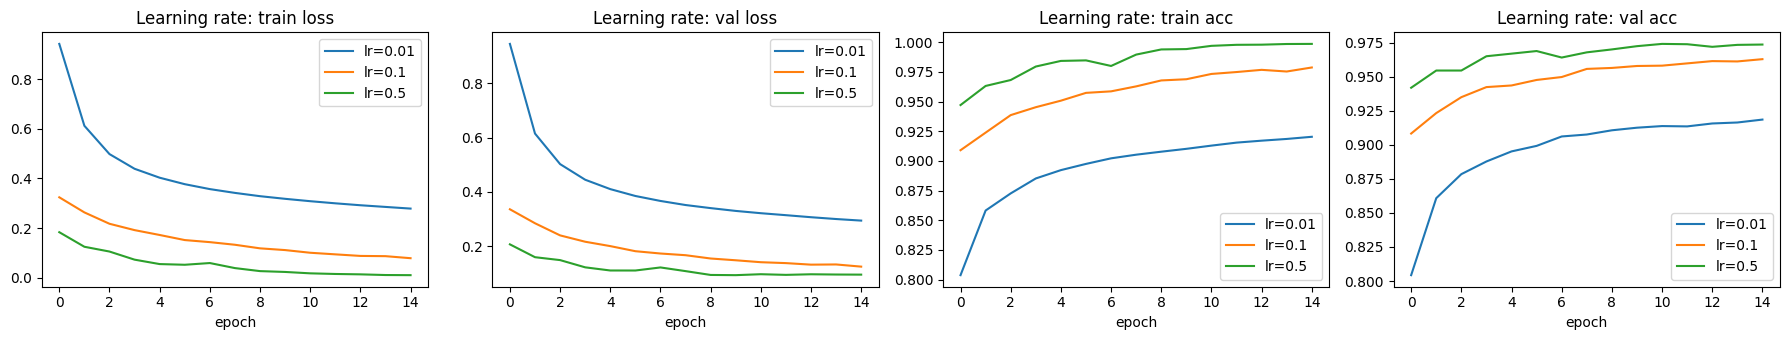

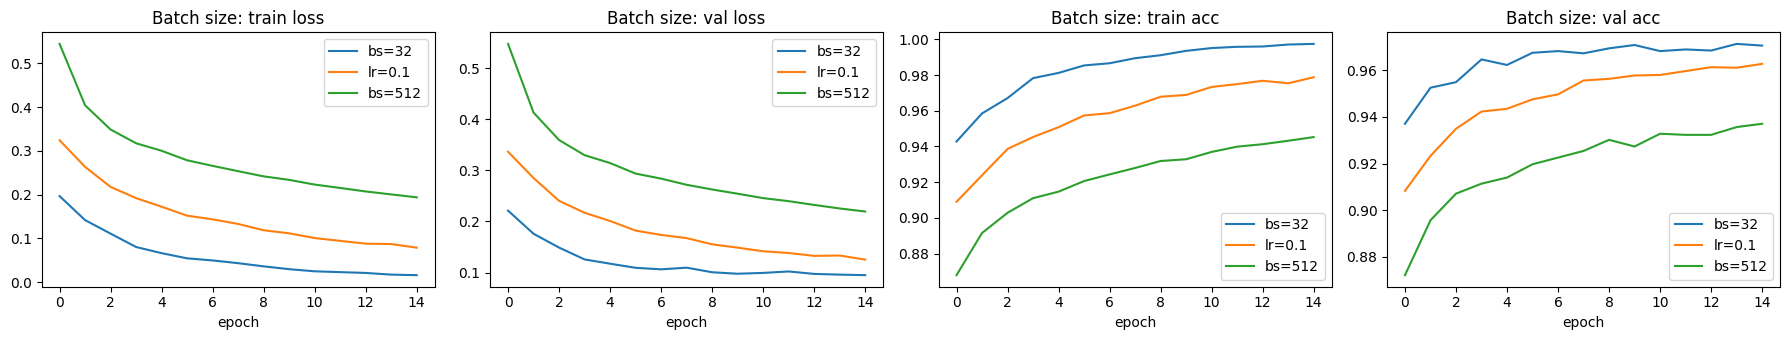

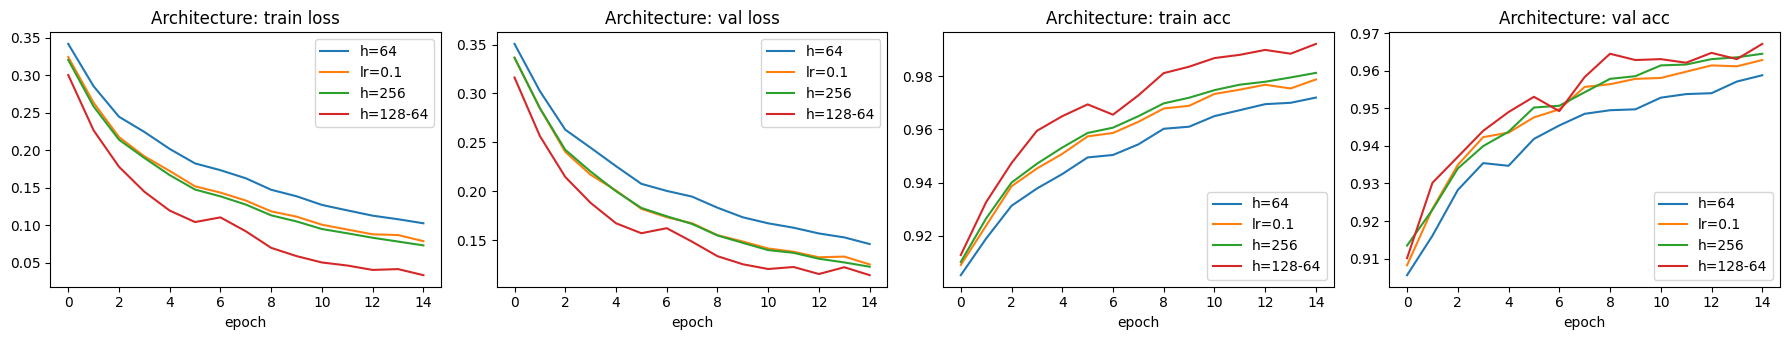

In [31]:
groups = {
    'Learning rate': ['lr=0.01', 'lr=0.1', 'lr=0.5'],
    'Batch size':    ['bs=32', 'lr=0.1', 'bs=512'],       # lr=0.1 is the bs=128 baseline
    'Architecture':  ['h=64', 'lr=0.1', 'h=256', 'h=128-64'],
}
for title, names in groups.items():
    fig, ax = plt.subplots(1, 4, figsize=(18, 3.5))
    for nm in names:
        h = results[nm]['hist']
        ax[0].plot(h['train_loss'], label=nm); ax[1].plot(h['val_loss'], label=nm)
        ax[2].plot(h['train_acc'], label=nm);  ax[3].plot(h['val_acc'], label=nm)
    for a, t in zip(ax, ['train loss', 'val loss', 'train acc', 'val acc']):
        a.set_title(f'{title}: {t}'); a.set_xlabel('epoch'); a.legend()
    plt.tight_layout(); plt.show()

In [32]:
rows = []
for nm, r in results.items():
    h = r['hist']
    rows.append(dict(run=nm, layers=r['cfg']['layer_sizes'], lr=r['cfg']['lr'], batch=r['cfg']['batch_size'],
                     train_acc=round(h['train_acc'][-1], 4), val_acc=round(h['val_acc'][-1], 4),
                     val_loss=round(h['val_loss'][-1], 4), time_s=round(r['time'], 1)))
results_df = pd.DataFrame(rows)
results_df

,run,layers,lr,batch,train_acc,val_acc,val_loss,time_s
0,lr=0.01,"[784, 128, 10]",0.01,128,0.9203,0.9185,0.2948,24.7
1,lr=0.1,"[784, 128, 10]",0.10,128,0.9788,0.9628,0.1254,24.5
2,lr=0.5,"[784, 128, 10]",0.50,128,0.9987,0.9735,0.0959,21.4
3,bs=32,"[784, 128, 10]",0.10,32,0.9974,0.9707,0.0950,31.3
4,bs=512,"[784, 128, 10]",0.10,512,0.9453,0.9371,0.2194,22.2
5,h=64,"[784, 64, 10]",0.10,128,0.9720,0.9588,0.1462,14.6
6,h=256,"[784, 256, 10]",0.10,128,0.9812,0.9645,0.1230,41.8
7,h=128-64,"[784, 128, 64, 10]",0.10,128,0.9921,0.9671,0.1144,23.7


## Final evaluation

In [33]:
best_name = max(results, key=lambda k: results[k]['hist']['val_acc'][-1])
print('best run:', best_name)
best_params = results[best_name]['params']

y_pred = predict(X_test, best_params)
print('test accuracy:', np.mean(y_pred == y_test))

best run: lr=0.5
test accuracy: 0.9707769066286529


,precision,recall,f1,support
0,0.9714,0.9855,0.9784,414
1,0.9850,0.9787,0.9818,469
2,0.9578,0.9761,0.9669,419
3,0.9721,0.9587,0.9654,436
4,0.9779,0.9755,0.9767,408
5,0.9758,0.9553,0.9654,380
6,0.9785,0.9880,0.9832,415
7,0.9560,0.9864,0.9710,441
8,0.9773,0.9509,0.9639,407
9,0.9568,0.9500,0.9534,420


accuracy        : 0.9707769066286529
macro precision : 0.9709
macro recall    : 0.9705
macro F1        : 0.9706


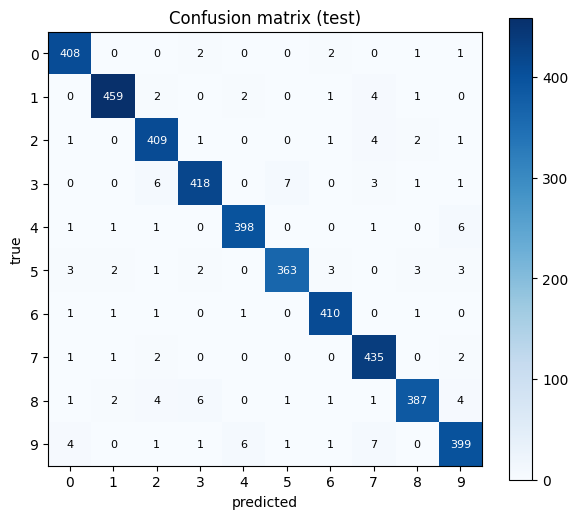

In [34]:
# confusion matrix, precision, recall, F1 computed by hand
cm = np.zeros((10, 10), dtype=int)
np.add.at(cm, (y_test, y_pred), 1)          # rows = true, cols = predicted

tp = np.diag(cm).astype(float)
precision = tp / np.maximum(cm.sum(axis=0), 1)
recall    = tp / np.maximum(cm.sum(axis=1), 1)
f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

metrics = pd.DataFrame({'precision': precision, 'recall': recall, 'f1': f1, 'support': cm.sum(axis=1)}).round(4)
display(metrics)
print('accuracy        :', tp.sum() / cm.sum())
print('macro precision :', precision.mean().round(4))
print('macro recall    :', recall.mean().round(4))
print('macro F1        :', f1.mean().round(4))

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Confusion matrix (test)'); plt.colorbar()
plt.show()

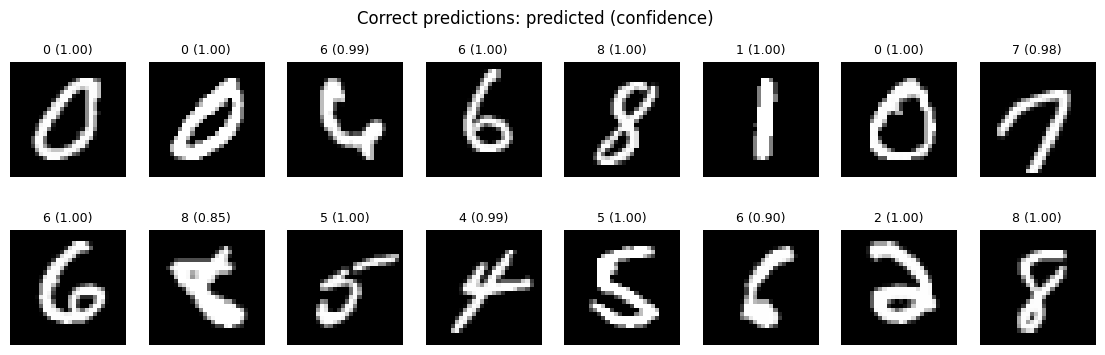

In [35]:
# correct predictions with confidence
A_test, _ = forward(X_test, best_params)
conf = A_test.max(axis=1)

correct = np.where(y_pred == y_test)[0]
pick = np.random.default_rng(1).choice(correct, 16, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, i in zip(axes.ravel(), pick):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray'); ax.axis('off')
    ax.set_title(f'{y_pred[i]} ({conf[i]:.2f})', fontsize=9)
plt.suptitle('Correct predictions: predicted (confidence)'); plt.show()

123 misclassified out of 4209


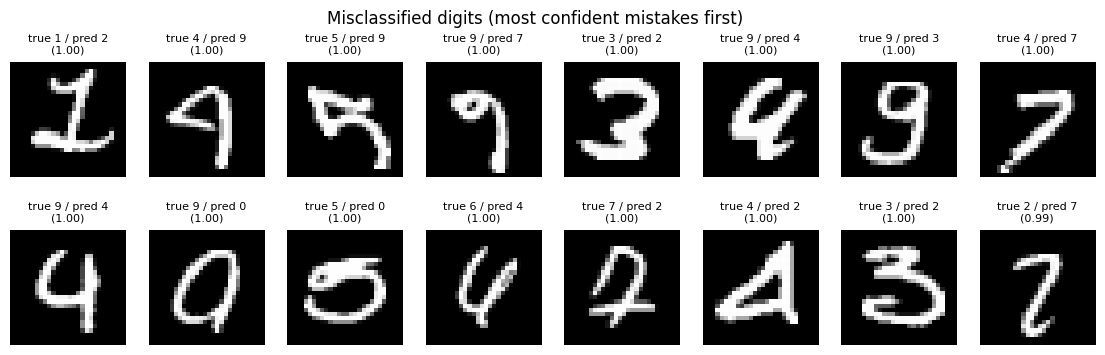

true 9 predicted as 7: 7 times
true 3 predicted as 5: 7 times
true 9 predicted as 4: 6 times
true 8 predicted as 3: 6 times
true 4 predicted as 9: 6 times
true 3 predicted as 2: 6 times
true 9 predicted as 0: 4 times
true 8 predicted as 9: 4 times


In [36]:
# misclassified digits
wrong = np.where(y_pred != y_test)[0]
print(len(wrong), 'misclassified out of', len(y_test))
show = wrong[np.argsort(-conf[wrong])][:16]            # the most confident mistakes
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, i in zip(axes.ravel(), show):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray'); ax.axis('off')
    ax.set_title(f'true {y_test[i]} / pred {y_pred[i]}\n({conf[i]:.2f})', fontsize=8)
plt.suptitle('Misclassified digits (most confident mistakes first)'); plt.show()

# most common confusions
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = [(off[i, j], i, j) for i in range(10) for j in range(10) if off[i, j] > 0]
for c, i, j in sorted(pairs, reverse=True)[:8]:
    print(f'true {i} predicted as {j}: {c} times')